Simuler l'impact sur les cas détectés : $\mu = 0,02$.
Simuler l'impact sur toute la population infectée : entre $\mu = 0,005$ et $\mu = 0,007$
Le taux varie de $\mu = 0,00001$ chez les jeunes à plus de $\mu = 0,08$ chez les très âgés

**Le taux de létalité apparent (CFR) : Santé publique France**

Ce taux est calculé sur les cas confirmés par tests. Il était très élevé au début de 2020 (plus de 15 %) car on ne testait que les malades hospitalisés.

Lien vers les archives : [Points épidémiologiques hebdomadaires](https://www.santepubliquefrance.fr/maladies-et-traumatismes/maladies-et-infections-respiratoires/infection-a-coronavirus/documents/bulletin-national/)

Conseil : Consultez le rapport du 15 mars 2020 (début) ou celui du 28 janvier 2021 (bilan de la première année) pour voir l'évolution des chiffres.

**Analyse globale 2020/2021 : La DREES et l'INSEE**

Pour les statistiques consolidées sur les causes réelles de décès par rapport à la population générale :

Rapport DREES (Décembre 2022) : [Le COVID-19, troisième cause de décès en France en 2020](https://drees.solidarites-sante.gouv.fr/publications-communique-de-presse/etudes-et-resultats/covid-19-troisieme-cause-de-deces-en-france-en)

Rapport INSEE (Mai 2022) : Impact de l'épidémie : [95 000 décès de plus qu'attendus en 2020-2021](https://www.insee.fr/fr/statistiques/6445335)

**À noter** : Le coefficient de mortalité $\mu$ a radicalement changé début 2021 avec l'arrivée du variant Alpha (plus létal) puis du variant Delta, avant de chuter significativement avec la campagne de vaccination et l'arrivée du variant Omicron.

___________________________________________________________________________________________________

Le taux de contagion journalier pour le covid est de 0.6 personne par jour
Le nombre de jour où une personne est contagieuse est de 5 jours
Le pourcentage de décès en France est d'environ 0.42%

Les premiers cas de COVID-19 ont été détectés en France en janvier 2020. La pandémie a été déclarée par l'OMS, le 11 mars.
https://www.santepubliquefrance.fr/maladies-et-traumatismes/maladies-et-infections-respiratoires/covid-19/le-scan/#tabs

La campagne de vaccination a débuté le 27 décembre 2020. Il s'est écoulé environ 336 jours depuis la découverte du patient 0 en France (on a pris la date du 27 janvier 2020 comme $t_0$)

Le taux de vaccination $\omega(t)$ n'est pas une constante. Il a évolué au fur à et mesure que la campagne de vaccination s'élargissait.

Pour commencer, on va supposer que ceux qui ont eu l'infection et ceux qui ont eu le vaccin, ont la même immunité dans le temps, soit 6 mois (180 jours)

On va combiner les modèles SIRDV et SIRD développés de sorte que 



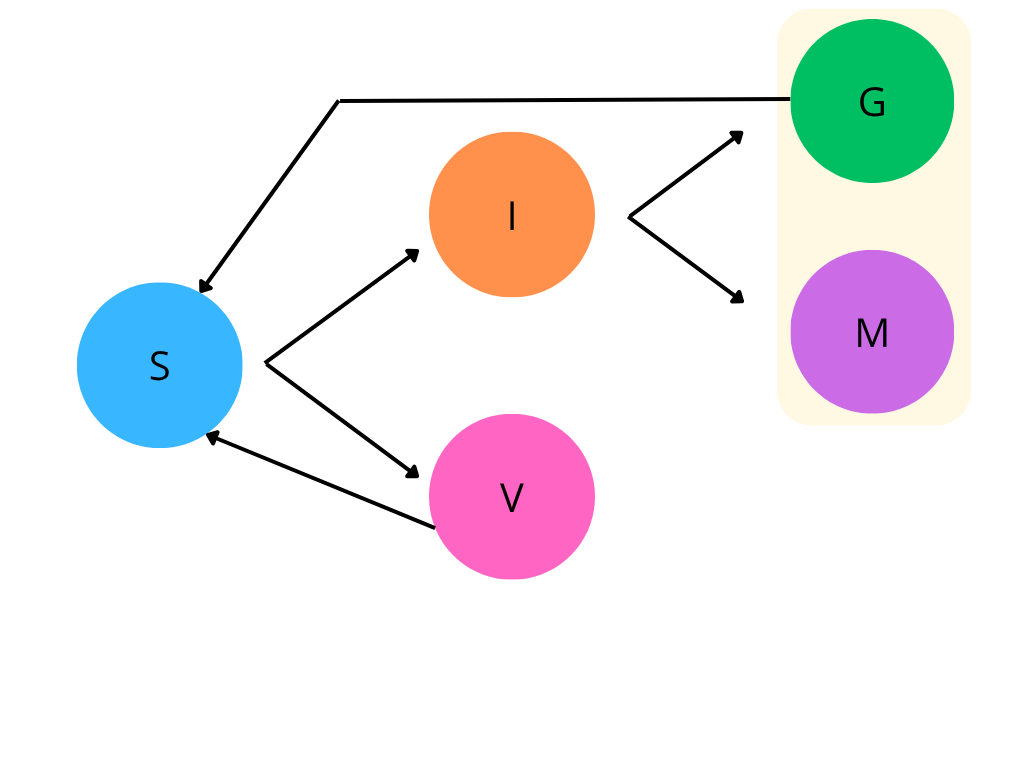

$$\frac{dS}{dt} = -\beta IS - \omega S + \rho V + \rho R$$
$$\frac{dI}{dt} = \beta IS - \mu I - \gamma I$$
$$\frac{dR}{dt} = \gamma I - \rho R$$
$$\frac{dD}{dt} = \mu I$$
$$\frac{dV}{dt} = \omega S - \rho V$$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent
V_init=0 # personnes vaccinées

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.007 # Coefficient de décès
omega= 0.009 # Taux de personnes vaccinées (valeur non réelle)
rho= 0.0055 # Taux de perte d'immunité par jour (6 mois)
t_start= 336 # Date de début de vaccination
R0=beta/(gamma+mu)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [15]:
dt = 0.1
tmax = 500.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
V = np.empty(n)
Rt = np.empty(n)

y = np.empty(5)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init
y[4] = V_init

params={"beta":beta, "gamma":gamma, "mu":mu, "omega":omega, "rho":rho, "t_start":t_start}
model=mathUtils.COVID19(params)
deriv=model.deriv
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    V[i] = y[4]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [3]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de V(t)")
plt.plot(temps, V)
plt.xlabel("temps")
plt.ylabel("V(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sird_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sird_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de D(t)")\nplt.plot(temps, D)\nplt.xlabel("temps")\nplt.ylabel("D(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de V(t)")\nplt.plot(temps, V)\nplt.xlabel("temps")\nplt.ylabel("V(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sird_Rt.pdf", bbox_inches=\

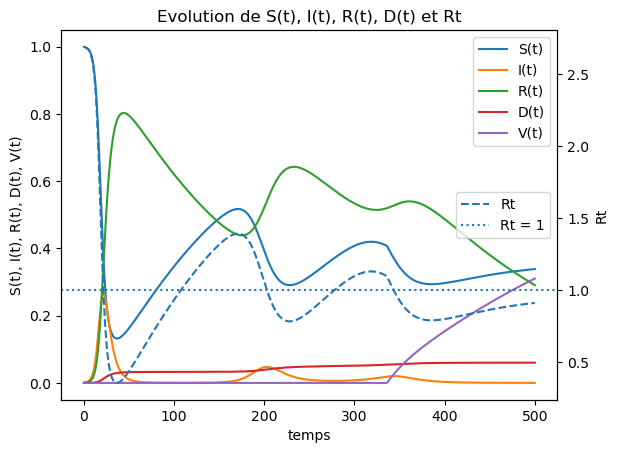

In [16]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t), D(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.plot(temps, V, label="V(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t), V(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("modélisation covid19.pdf", bbox_inches='tight')
plt.show()

La campagne de vaccination n'a pas été uniforme, elle s'est élargie au cours du temps. En effet, la vaccination a été d'abord dédiée aux personnes agées, puis vulnérables avant d'être ouverte à un plus large public.

Recommandation HAS au 27 novembre 2020
Priorité 1 : Populations soumises à 2 facteurs risques : âge et exposition au virus
Priorité 2 : Personnes de + 75 ans
             Personne de 65/74 ans avec maladie
             Personnels de santé de + 50 ans


Etapes vaccination : 
1/ Début de la vaccination avant Noel 2020
2/ Vaccination privilégiée chez les plus fragiles (+ de 75 ans). Au 14 janvier, environ 500 000 personnes sont vaccinées (~ 0.0075 = 0,075%)
3/ Arrivée d'un deuxième vaccin (entreprise Moderna) en France puis d'un troisième (Vaccin AstraZeneca). 12 mars, vaccin Janssen autorisé (une seule dose nécessitée). Début mars, 2 millions de francais sont vaccinées entièrement (~0.0299 = 2,99%)
4/ Fin mai, tous les + de 18 ans peuvent recevoir le vaccin. 25 millions (~0.3731 = 37,31%) ont eu une première dose et 10 millions sont vaccinées complètement

Jusqu'à maintenant, on utilisait un taux constant pour la vaccination. C'est la forme la plus simple qui sert de référence pour comparer à d'autres modèles. Pour autant la vaccination dépend de multiples facteurs, ce qui rend ce modèle erroné. 
Différents modèles possibles :
Constant
Sinusoïdale : pour les maladies saisonnières comme la grippe
Sigmoïde logistique : pour l'adoption progressive d'un nouveau vaccin

**v(t) = v_max / (1 + exp(−k·(t − t₀))) — Sigmoïde logistique**
Intérêt mathématique : La sigmoïde est la solution de l'équation logistique dv/dt = k·v·(1 − v/v_max), ce qui lui donne une justification dynamique naturelle : le taux de vaccination croît d'abord exponentiellement puis ralentit à l'approche de la saturation.
Ce qu'elle modélise : L'adoption progressive d'une nouvelle technologie vaccinale dans une population hésitante ou mal informée. Un modèle dynamique basé sur la fonction logistique a été construit pour quantifier l'élimination de l'hésitation vaccinale face au COVID-19, montrant que la dynamique d'adoption suit une courbe en S. Plus concrètement, la sigmoïde capture la transition entre : (1) une phase lente initiale (réticences, manque d'information, capacité limitée) ; (2) une accélération centrale (contagion sociale, communication de masse) ; (3) une saturation finale (population cible vaccinée).
Cas d'usage documenté : Des modèles de déploiement vaccinal COVID-19 ont utilisé une fonction sigmoïdale dépendant du temps pour capturer la croissance progressive des variants préoccupants et mieux prédire la trajectoire de l'infection et l'efficacité des vaccins.
https://link.springer.com/article/10.1186/s12889-022-13597-9
https://pmc.ncbi.nlm.nih.gov/articles/PMC9922755/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent
V_init=0 # personnes vaccinées

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.007 # Coefficient de décès
omega= 0.009 # Taux de personnes vaccinées (valeur non réelle)
rho= 0.0055 # Taux de perte d'immunité par jour (6 mois)
t_start= 336 # Date de début de vaccination
R0=beta/(gamma+mu)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [2]:
dt = 0.1
tmax = 800.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
V = np.empty(n)
Rt = np.empty(n)

y = np.empty(5)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init
y[4] = V_init

params={
    "beta":beta,
    "gamma":gamma, 
    "mu":mu, 
    "omega":0.02, 
    "rho":rho, 
    "t_start":t_start,
    "k": 0.04
    }
model=mathUtils.COVID19(params)
deriv=model.deriv_sigmo
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    V[i] = y[4]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [3]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de V(t)")
plt.plot(temps, V)
plt.xlabel("temps")
plt.ylabel("V(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sird_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sird_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de D(t)")\nplt.plot(temps, D)\nplt.xlabel("temps")\nplt.ylabel("D(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de V(t)")\nplt.plot(temps, V)\nplt.xlabel("temps")\nplt.ylabel("V(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sird_Rt.pdf", bbox_inches=\

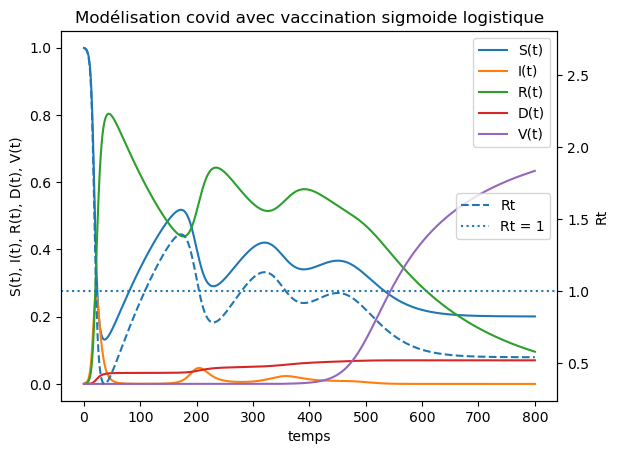

In [4]:
plt.figure()
plt.title("Modélisation covid avec vaccination sigmoide logistique")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.plot(temps, V, label="V(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t), V(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("modélisation covid19 sigmo.pdf", bbox_inches='tight')
plt.show()